## Setup

In [1]:
import xarray as xr
from pathlib import Path
import random
import datetime
import numpy as np
from matplotlib import pyplot as plt

In [ ]:
# directory with source files 
data_dir = Path('/import/beegfs/CMIP6/arctic-cmip6/Arctic_Rivers_Data')

# load combined outputs
wt_ds = xr.open_dataset('/import/beegfs/CMIP6/jdpaul3/arctic_rivers/combined_wt.nc')
q_ds = xr.open_dataset('/import/beegfs/CMIP6/jdpaul3/arctic_rivers/combined_q.nc')

# load daily climatologies
wt_clim_ds = xr.open_dataset('/import/beegfs/CMIP6/jdpaul3/arctic_rivers/daily_clim_wt.nc')
q_clim_ds = xr.open_dataset('/import/beegfs/CMIP6/jdpaul3/arctic_rivers/daily_clim_q.nc')

# load stats
q_stats_ds = xr.open_dataset('/import/beegfs/CMIP6/jdpaul3/arctic_rivers/stats_q.nc')

## QC combined values against source data

In [5]:
def compare_combined_file_with_source_data(variable, combined_ds):
    # for each model, and a random stream id,
    # check a random historical date (1990-2021) and a random future date (2034-2065)
    # make sure the values match the source files
    # source file naming convention is YYYY_model_<variable>.nc, with variable being "WT" or "Q"
    # to find the file names, we add "h" prefix to the model name for historical and "f" prefix for future
    # (not applicable to the "historical" model, which is historical period only)

    models = combined_ds.model.values
    stream_id = random.choice(combined_ds.stream_id.values)
    historical_date = np.datetime64(datetime.date(random.randint(1990, 2021), random.randint(1, 12), random.randint(1, 28)))
    future_date = np.datetime64(datetime.date(random.randint(2034, 2065), random.randint(1, 12), random.randint(1, 28)))

    # we can't have any dates past 10-01-2021 for historical, or past 10-01-2065 for future. If we do, just set these to 10-01 of that year
    if historical_date > np.datetime64('2021-10-01'):
        historical_date = np.datetime64('2021-10-01')
    if future_date > np.datetime64('2065-10-01'):
        future_date = np.datetime64('2065-10-01')

    # there is also a date shifting problem with the NCAR model ensemble members.
    # this only affects dates in the first 2 weeks of January and the last 2 weeks of December of any year
    # for these dates, we will just shift them to Jan 15 or Dec 15
    if historical_date < np.datetime64(f"{historical_date.astype('datetime64[Y]').item().year}-01-15"):
        historical_date = np.datetime64(f"{historical_date.astype('datetime64[Y]').item().year}-01-15")
    if historical_date > np.datetime64(f"{historical_date.astype('datetime64[Y]').item().year}-12-15"):
        historical_date = np.datetime64(f"{historical_date.astype('datetime64[Y]').item().year}-12-15")
    if future_date < np.datetime64(f"{future_date.astype('datetime64[Y]').item().year}-01-15"):
        future_date = np.datetime64(f"{future_date.astype('datetime64[Y]').item().year}-01-15")
    if future_date > np.datetime64(f"{future_date.astype('datetime64[Y]').item().year}-12-15"):
        future_date = np.datetime64(f"{future_date.astype('datetime64[Y]').item().year}-12-15")
        
        
    for model in models:
        source_file_hist = data_dir / f"{historical_date.astype('datetime64[Y]').item().year}_{'h' + model if model != 'historical' else model}_{variable}.nc"
        source_file_fut = data_dir / f"{future_date.astype('datetime64[Y]').item().year}_{'f' + model if model != 'historical' else model}_{variable}.nc"

        if variable == "Q":
            sel_dict = {"source_file_variable": "IRFroutedRunoff",
                "source_file_id": "seg"}

        elif variable == "WT":
            sel_dict = {"source_file_variable": "T_stream",
                "source_file_id": "hru",
                "additional_filter": {"no_seg": 1}}
            
        # load source files
        src_ds_hist = xr.open_dataset(source_file_hist)
        src_ds_fut = xr.open_dataset(source_file_fut)

        # standardize the time dimension to be all 0 hour to match combined dataset
        src_ds_hist['time'] = src_ds_hist['time'].dt.floor('D')
        src_ds_fut['time'] = src_ds_fut['time'].dt.floor('D')

        # all timestamps should be present in the combined datasets - if we get a KeyError: "not all values found in index 'time', print a warning and skip this timestep
        try:
            _ = combined_ds.sel(model=model, stream_id=stream_id).sel(time=historical_date)
        except KeyError as e:
            print(f"Warning: Combined dataset is missing data for model {model}, stream_id {stream_id}, historical date {historical_date}. Probably missing a timestep? Skipping this test case.")
            return None
        try: 
            _ = combined_ds.sel(model=model, stream_id=stream_id).sel(time=future_date)
        except KeyError as e:
            print(f"Warning: Combined dataset is missing data for model {model}, stream_id {stream_id}, future date {future_date}. Probably missing a timestep? Skipping this test case.")
            return None
        
        # get combined ds values
        combined_value_hist = combined_ds.sel(model=model, stream_id=stream_id).sel(time=historical_date)[sel_dict["source_file_variable"]].item()
        combined_value_fut = combined_ds.sel(model=model, stream_id=stream_id).sel(time=future_date)[sel_dict["source_file_variable"]].item()

        # convert the combined ds values to the same units as the source ds (cfs to cms for Q)
        if variable == "Q":
            combined_value_hist = combined_value_hist * 0.0283168
            combined_value_fut = combined_value_fut * 0.0283168

        # all timestamps might not be present in the source datasets - if we get a KeyError: "not all values found in index 'time', print a warning and skip this timestep
        # get source ds values
        if sel_dict.get("additional_filter") is not None:
            try:
                source_value_hist = src_ds_hist[sel_dict["source_file_variable"]].sel({sel_dict["source_file_id"]: stream_id}).sel(time=historical_date).sel(sel_dict["additional_filter"]).item()
            except KeyError as e:
                print(f"Warning: The source dataset is missing data for model {model}, stream_id {stream_id}, historical date {historical_date}. Probably missing a timestep? Skipping this test case.")
                print(e)
                return None
            try:
                source_value_fut = src_ds_fut[sel_dict["source_file_variable"]].sel({sel_dict["source_file_id"]: stream_id}).sel(time=future_date).sel(sel_dict["additional_filter"]).item()
            except KeyError as e:
                print(f"Warning: The source dataset is missing data for model {model}, stream_id {stream_id}, future date {future_date}. Probably missing a timestep? Skipping this test case.")
                print(e)
                return None
        else:
            try:
                source_value_hist = src_ds_hist[sel_dict["source_file_variable"]].sel({sel_dict["source_file_id"]: stream_id}).sel(time=historical_date).item()
            except KeyError as e:
                print(f"Warning: The source dataset is missing data for model {model}, stream_id {stream_id}, historical date {historical_date}. Probably missing a timestep? Skipping this test case.")
                print(e)
                return None
            try:
                source_value_fut = src_ds_fut[sel_dict["source_file_variable"]].sel({sel_dict["source_file_id"]: stream_id}).sel(time=future_date).item()
            except KeyError as e:
                print(f"Warning: The source dataset is missing data for model {model}, stream_id {stream_id}, future date {future_date}. Probably missing a timestep? Skipping this test case.")
                print(e)
                return None
            

        # check that values are the same, and print any mismatches
        if not np.isclose(combined_value_hist, source_value_hist):
            print(f"Mismatch in historical value for model {model}, stream_id {stream_id}, date {historical_date}: combined {combined_value_hist}, source {source_value_hist}")
        if not np.isclose(combined_value_fut, source_value_fut):
            print(f"Mismatch in future value for model {model}, stream_id {stream_id}, date {future_date}: combined {combined_value_fut}, source {source_value_fut}")

        return None

In [6]:
# no output = all values match, passes QC
# run this function 100x to check different random values
for _ in range(100):
    compare_combined_file_with_source_data("Q", q_ds)

In [7]:
# no output = all values match, passes QC
# run this function 100x to check different random values
for _ in range(100):
    compare_combined_file_with_source_data("WT", wt_ds)

## QC Daily Climatologies 

In [8]:
# function to test for nans, use where we know there should be nans!
# no output means the test passed
def test_for_nans(ds, model, stream_id, era):
    for var in ds.data_vars:
        values = ds[var].sel(model=model, stream_id = stream_id, era=era).values
        if not np.isnan(values).all():
            print(f"FAIL: Expected all NaN values but found some data for model {model}, stream_id {stream_id}, era {era}, variable {var}")

# function to test for values, use where we know there should be some data
# no output means the test passed
def test_for_values(ds, model, stream_id, era):
    for var in ds.data_vars:
        values = ds[var].sel(model=model, stream_id = stream_id, era=era).values
        if np.isnan(values).all():
            print(f"FAIL: Expected some data values but found all NaN for model {model}, stream_id {stream_id}, era {era}, variable {var}")

In [9]:
stream_id = random.choice(wt_ds.stream_id.values)
model="historical"
era="2034-2065"

test_for_nans(wt_clim_ds, model, stream_id, era)
test_for_nans(q_clim_ds, model, stream_id, era)

In [10]:
stream_id = random.choice(wt_ds.stream_id.values)
model="PGWh" # future only
era="1990-2021"

test_for_nans(wt_clim_ds, model, stream_id, era)
test_for_nans(q_clim_ds, model, stream_id, era)

In [11]:
stream_id = random.choice(wt_ds.stream_id.values)
model="PGWm" # future only
era="1990-2021"

test_for_nans(wt_clim_ds, model, stream_id, era)
test_for_nans(q_clim_ds, model, stream_id, era)

In [12]:
stream_id = random.choice(wt_ds.stream_id.values)
model="historical"
era="1990-2021"

test_for_values(wt_clim_ds, model, stream_id, era)
test_for_values(q_clim_ds, model, stream_id, era)

In [13]:
stream_id = random.choice(wt_ds.stream_id.values)
model="C2LE7"
era="1990-2021"

test_for_values(wt_clim_ds, model, stream_id, era)
test_for_values(q_clim_ds, model, stream_id, era)

In [14]:
stream_id = random.choice(wt_ds.stream_id.values)
model="C2LE7"
era="2034-2065"

test_for_values(wt_clim_ds, model, stream_id, era)
test_for_values(q_clim_ds, model, stream_id, era)

In [15]:
# function to plot a hydrograph for a random stream to visually inspect
# plots doy_mean from all models for the historical era

def plot_hydrograph(ds, stream_id, era, variable_label):
    plt.figure(figsize=(10,6))
    for model in ds.model.values:
        doy_mean = ds['doy_mean'].sel(model=model, stream_id=stream_id, era=era)
        if doy_mean.isnull().all():
            print("dropping model with all nans:", model)
            continue
        plt.plot(doy_mean, label=model)
    plt.title(f"Daily {variable_label} Climatology Hydrograph for Stream ID {stream_id} ({era})")
    plt.xlabel("Day of Year")
    if variable_label == "Water Temperature":
        plt.ylabel("Temperature (°C)")
    elif variable_label == "Streamflow":
        plt.ylabel("Streamflow (cfs)")
    plt.legend()
    plt.grid()
    plt.show()

dropping model with all nans: PGWh
dropping model with all nans: PGWm


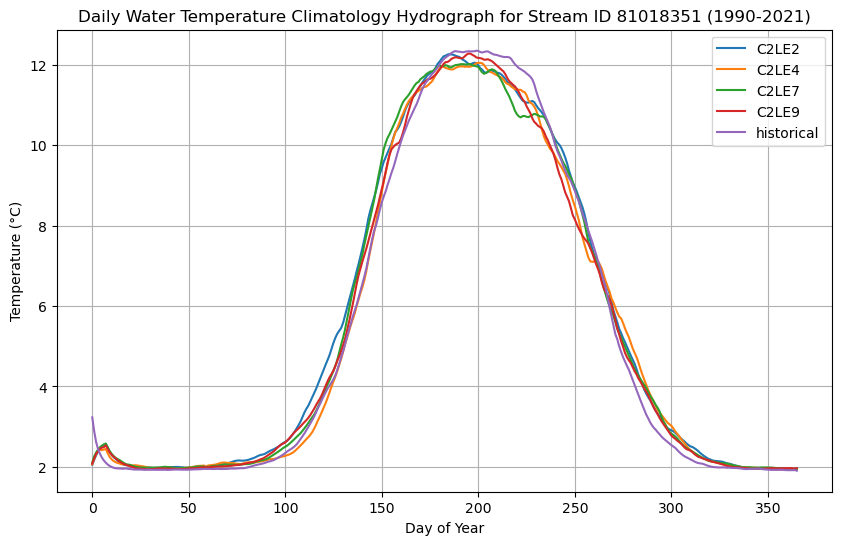

dropping model with all nans: PGWh
dropping model with all nans: PGWm


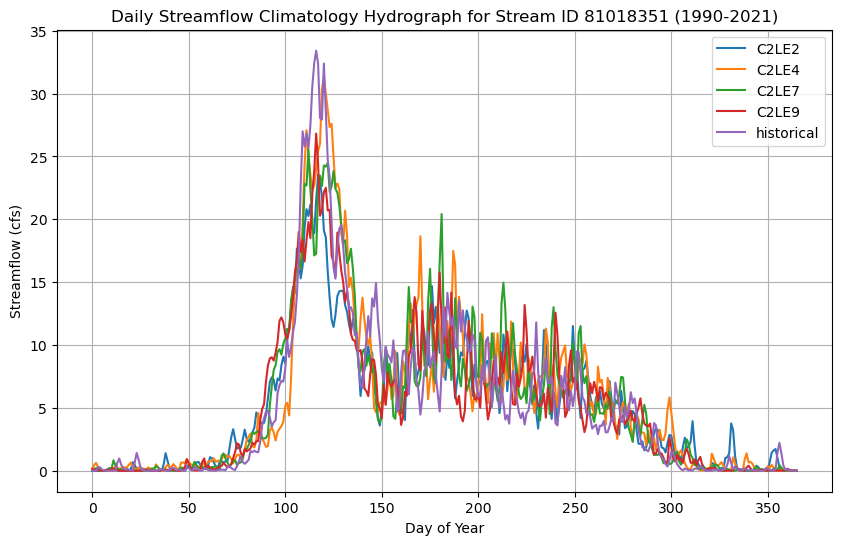

dropping model with all nans: historical


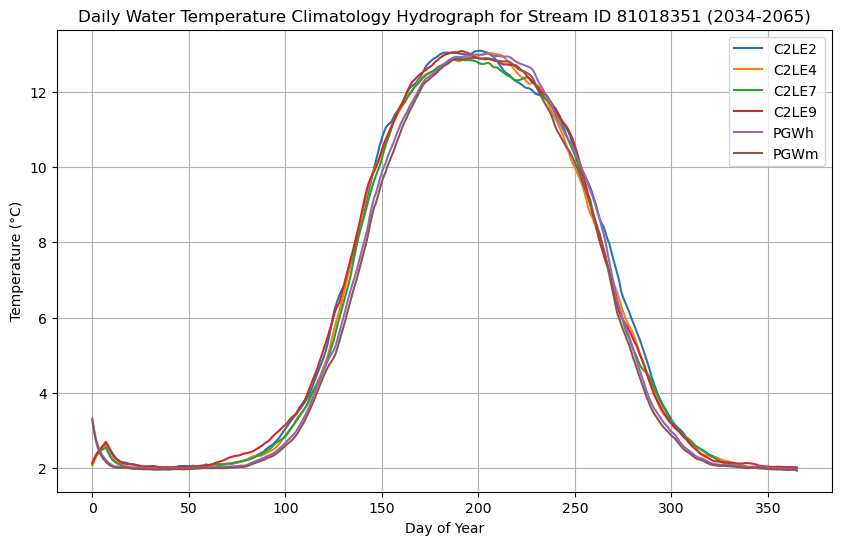

dropping model with all nans: historical


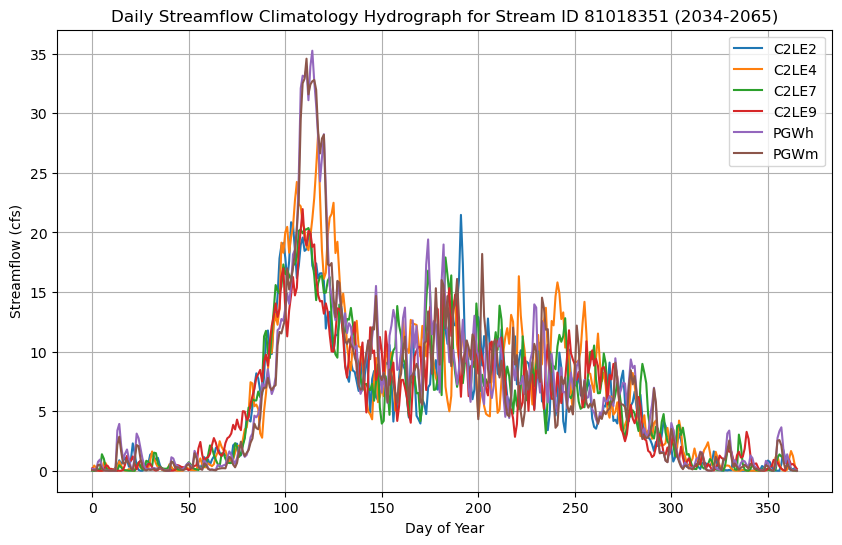

In [16]:
stream_id = random.choice(wt_ds.stream_id.values)
era="1990-2021"

plot_hydrograph(wt_clim_ds, stream_id, era, "Water Temperature")
plot_hydrograph(q_clim_ds, stream_id, era, "Streamflow")

era="2034-2065"

plot_hydrograph(wt_clim_ds, stream_id, era, "Water Temperature")
plot_hydrograph(q_clim_ds, stream_id, era, "Streamflow")

## QC Hydro Stats

In [17]:
# we can use the same nan/value check functions as above
stream_id = random.choice(q_stats_ds.stream_id.values)
model="historical"
era="2034-2065"

test_for_nans(q_stats_ds, model, stream_id, era)

In [18]:
stream_id = random.choice(q_stats_ds.stream_id.values)
model="PGWh" # future only
era="1990-2021"

test_for_nans(q_stats_ds, model, stream_id, era)

In [19]:
stream_id = random.choice(q_stats_ds.stream_id.values)
model="PGWm" # future only
era="1990-2021"

test_for_nans(q_stats_ds, model, stream_id, era)

In [20]:
stream_id = random.choice(q_stats_ds.stream_id.values)
model="historical"
era="1990-2021"

test_for_values(q_stats_ds, model, stream_id, era)

In [21]:
stream_id = random.choice(q_stats_ds.stream_id.values)
model="C2LE7"
era="1990-2021"

test_for_values(q_stats_ds, model, stream_id, era)

In [22]:
stream_id = random.choice(q_stats_ds.stream_id.values)
model="C2LE7"
era="2034-2065"

test_for_values(q_stats_ds, model, stream_id, era)

In [23]:
# function to plot a hydrograph for a random stream to visually inspect
# plots doy_mean from all models for the historical era
# also plots the monthly mean stats as points

stat_var_dict = {
        "ma12": {"month": 1, "description": "Mean of monthly flow values for January.", "units": "cfs"},
        "ma13": {"month": 2, "description": "Mean of monthly flow values for February.", "units": "cfs"},
        "ma14": {"month": 3, "description": "Mean of monthly flow values for March.", "units": "cfs"},
        "ma15": {"month": 4, "description": "Mean of monthly flow values for April.", "units": "cfs"},
        "ma16": {"month": 5, "description": "Mean of monthly flow values for May.", "units": "cfs"},
        "ma17": {"month": 6, "description": "Mean of monthly flow values for June.", "units": "cfs"},
        "ma18": {"month": 7, "description": "Mean of monthly flow values for July.", "units": "cfs"},
        "ma19": {"month": 8, "description": "Mean of monthly flow values for August.", "units": "cfs"},
        "ma20": {"month": 9, "description": "Mean of monthly flow values for September.", "units": "cfs"},
        "ma21": {"month": 10, "description": "Mean of monthly flow values for October.", "units": "cfs"},
        "ma22": {"month": 11, "description": "Mean of monthly flow values for November.", "units": "cfs"},
        "ma23": {"month": 12, "description": "Mean of monthly flow values for December.", "units": "cfs"},
    }

def plot_hydrograph_with_stats(clim_ds, stat_ds, stream_id, era, variable_label):
    plt.figure(figsize=(10,6))
    for model in clim_ds.model.values:
        # hydrograph line
        doy_mean = clim_ds['doy_mean'].sel(model=model, stream_id=stream_id, era=era)
        if doy_mean.isnull().all():
            print("dropping model with all nans:", model)
            continue
        plt.plot(doy_mean, label=model)
        # stats points
        for stat_var, stat_info in stat_var_dict.items():
            month = stat_info["month"]
            # get the day of year for the 15th of the month
            day_of_year = (datetime.date(2001, month, 15) - datetime.date(2001, 1, 1)).days + 1
            stat_value = stat_ds[stat_var].sel(model=model, stream_id=stream_id, era=era).item()
            if not np.isnan(stat_value):
                plt.plot(day_of_year, stat_value, marker='o', markersize=8, label=f"{model} {stat_var}")

    plt.title(f"Daily {variable_label} Climatology Hydrograph with Mean Monthly Flow Points for Stream ID {stream_id} ({era})")
    plt.xlabel("Day of Year")
    if variable_label == "Water Temperature":
        plt.ylabel("Temperature (°C)")
    elif variable_label == "Streamflow":
        plt.ylabel("Streamflow (cfs)")
    plt.legend()
    plt.grid()
    plt.show()

dropping model with all nans: PGWh
dropping model with all nans: PGWm


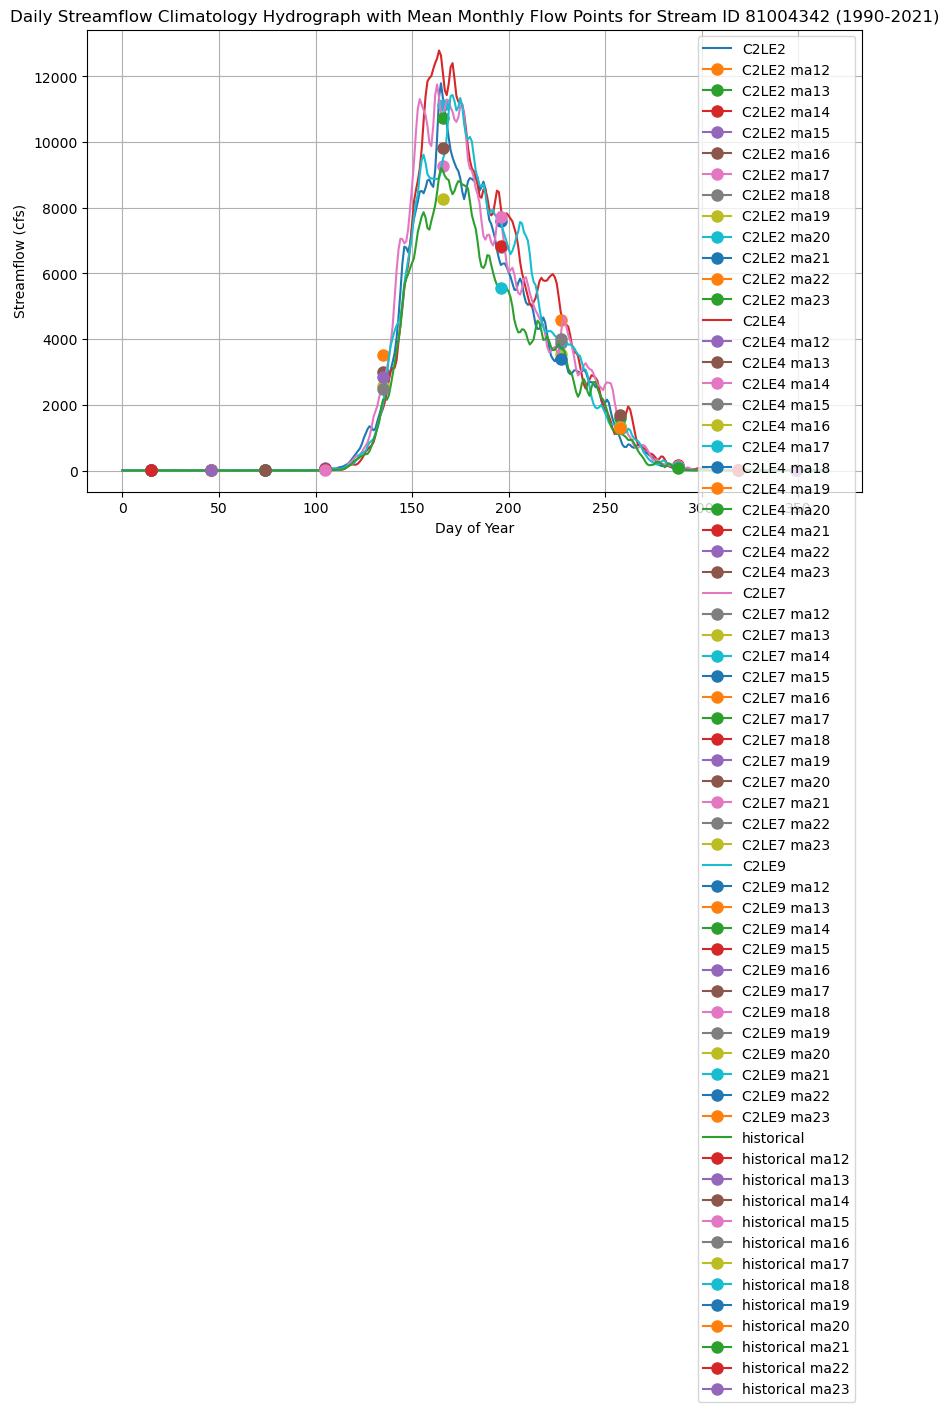

dropping model with all nans: historical


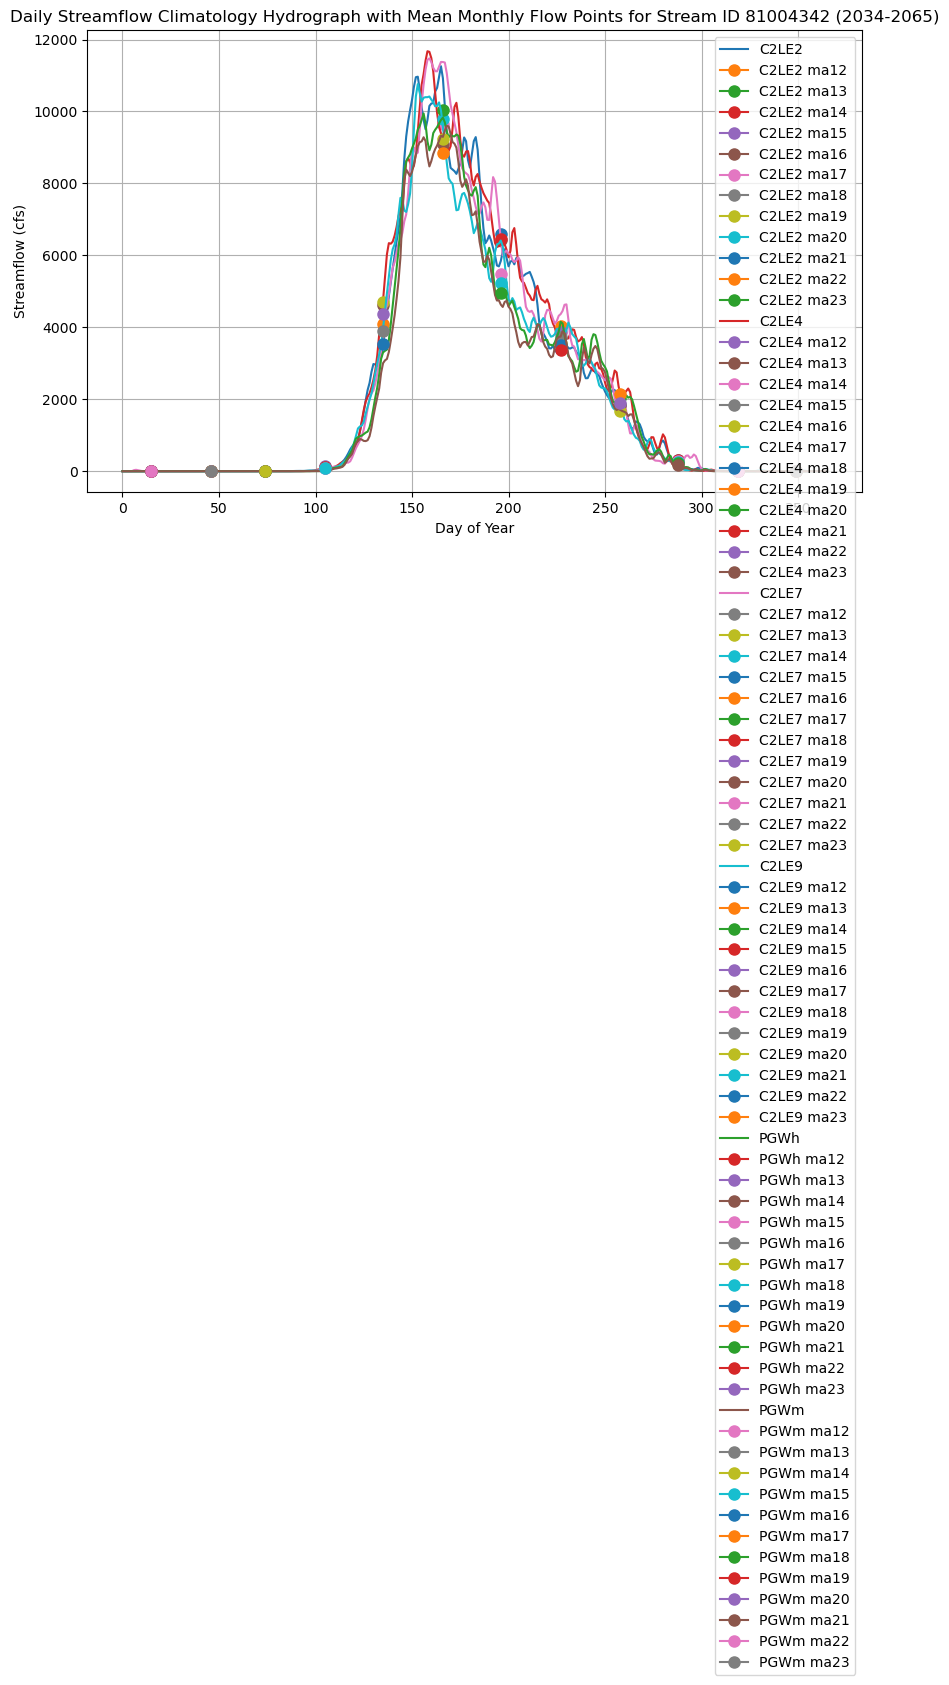

In [24]:
stream_id = random.choice(q_stats_ds.stream_id.values)
era="1990-2021"

plot_hydrograph_with_stats(q_clim_ds, q_stats_ds, stream_id, era, "Streamflow")

era="2034-2065"
plot_hydrograph_with_stats(q_clim_ds, q_stats_ds, stream_id, era, "Streamflow")